# Imports And Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [2]:
daily_df = pd.read_csv("data/processed/adelaide_daily_weather_cleaned.csv", index_col="datetime_local")
daily_df.index = pd.to_datetime(daily_df.index, utc=True).tz_convert("Australia/Adelaide")
daily_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,precipitation,wind_direction_compass,severity,heat_wave
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,12.29,19.740000,-8.062083,-1.385000,-8.062083,0.0,0.0,SE,No-heatwave,False
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,13.89,25.490000,-7.820417,-0.857500,-7.820417,0.0,0.0,SE,No-heatwave,False
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,12.79,25.189999,-8.895417,-2.030833,-8.895417,0.0,0.0,SE,No-heatwave,False
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,13.14,20.340000,-9.395417,-2.589167,-9.395417,0.0,0.0,S,No-heatwave,False
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,11.89,21.039999,-8.628750,-1.765000,-8.628750,0.0,0.0,S,No-heatwave,False


In [3]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9132 entries, 2000-01-01 00:00:00+10:30 to 2024-12-31 00:00:00+10:30
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   relative_humidity_2m     9132 non-null   float64
 1   dew_point_2m             9132 non-null   float64
 2   apparent_temperature     9132 non-null   float64
 3   pressure_msl             9132 non-null   float64
 4   wind_speed_10m           9132 non-null   float64
 5   cloud_cover              9132 non-null   float64
 6   shortwave_radiation      9132 non-null   float64
 7   wet_bulb_temperature_2m  9132 non-null   float64
 8   month_local              9132 non-null   float64
 9   wind_unit_x              9132 non-null   float64
 10  wind_unit_y              9132 non-null   float64
 11  DMT                      9132 non-null   float64
 12  tmin                     9132 non-null   float64
 13  tmax                     9132 

# Introduction and Motivation

There can be different ways to predict heatwaves and/or their severity. Two main ways are:
* Predicting ``EHF`` values as *regression*, by using root and derived past days' *(and some of current day's)* feature values.
* Predicting heatwave days as *binary classification* task, by using root and derived past days' *(and some of current day's)* feature values. 

**!!!!**
We want to focus to latter option, predciting as binary classification. Thus, our question becomes, *"Today is a heatwave day or not given a set of features?"*. There are important points those we have to keep in mind and make clear right now:
1. A **heatwave day** is a day with a $EHF > 0$ value. Thus, if day's ``EHF`` is greater than 0, it is a heatwave day; and vice versa, if day's ``EHF`` is less than 0, it is not a heatwave day. By definition ``EHF`` value covers current day and 2 consecutive days, totall 3 sequential days. 
2. When we were mentioning about our two predcition options above we've used an statement, "*(and some of current day's)*". We meant we can use some of current day's feature values optionally, on top of the features originated from past days' values. This is normally can be seen as a **data leakage**. Normally, we don't have access to current day's feature values while predicting one of today's variables. 

**BUT**, if we think on that our main heatwave defining variable `EHF` is actually today's plus next 2 days' value, even we use and show it as a only today's value. Thus, technically we can use past *and some of current day's* feature values to predict that if today is a heatwave day or not, in other words, *Will todays ``EHF`` be greater than 0?*. Implicitly, we would do a prediction for next 2 days' conditions. This would be thought as a short term forecast. Eventually, this is going to be our primitive modelling task.

*Why we choose this modelling task, binary classification?:* Binary classification is more simple and less complex than predicting direct `EHF` or `DMT` values. That's why we choose binary classification at first place. If problem could be solved with this way, it would be handled with relatively simplest and also more interpretable way. 


**Feature Types and Candidate Variables**

Before we dive into action, let's have a look at our main feature types.

* **Lag Features:** Features past days' values. For example, ``relative_humidity_2m_lag1`` means 1 day before current day's ``relative_humidity_2m`` value.
* **Rolling Features**: A spesific size window of past days' aggregated values, like *Mean, Std, Max, Min, Sum, etc.*. For example, ``relative_humidity_2m_avg3`` means previous 3 days' average of ``relative_humidity_2m`` values.
* **Month Features:** Features that are cyclic in nature. Like **month** and **wind direction** features. In this way, model would be able to learn informations like, 12th month December and 1st month January are next to each other. We've done this already for wind direction, we are going to do this for month cyclic features here. Also previous years month values might be usefull because of yearly seasonality. 

**!** We are going to mention about using *some of current day's features* later.

Let's start with **Lag Features**.

# Lag Features
We are encoding lag feature names as ``{feature_name}_lag{lag_day}``. For example, ``relative_humidity_2m_lag1`` means 1 day before current day's ``relative_humidity_2m`` value. 

Let's have a look root features that we are going to derive lag features from.

In [ ]:
numeric_columns = list(daily_df.select_dtypes(include=['number']).columns)
numeric_columns.remove('month_local') # Actually categorical
numeric_columns
# Basically all numeric columns

['relative_humidity_2m',
 'dew_point_2m',
 'apparent_temperature',
 'pressure_msl',
 'wind_speed_10m',
 'cloud_cover',
 'shortwave_radiation',
 'wet_bulb_temperature_2m',
 'wind_unit_x',
 'wind_unit_y',
 'DMT',
 'tmin',
 'tmax',
 'EHI_sig',
 'EHI_accl',
 'EHF',
 'EHF_sev',
 'precipitation']

**!!** To avoid data leakage, we need to be very careful some of these features, which are heatwave index features: `EHI_sig, EHI_accl, EHF, EHF_sev`. Because by definition these features refers current day and 2 consecutive days. So, if use *lag1 or lag2*, we would use tomarrow's and day after tomorrow's temperature values. That contradicts our decided modelling task, in other words **data leakage.** Because of this fact, instead, we use **lag3, lag4 and lag5** for these features. No worries about *lag3*: Its last required `DMT` value is yesterday's. Which derived with temperature values from **yesterday 9am to today 9am**. Since we've decided to use todays' features (with a few exception, we will explain later), this is not a problem, is an acceptable feature.

In [ ]:
lag_df = daily_df.copy().loc[:, numeric_columns]

# Genearate first 3 lags for numeric columns
for col in numeric_columns:
    if col.startswith('EH'): 
        lag_df[f'{col}_lag3'] = lag_df[col].shift(3)
        lag_df[f'{col}_lag4'] = lag_df[col].shift(4)
        lag_df[f'{col}_lag5'] = lag_df[col].shift(5)
        # ! These variables are derived from temperatures of day when instance was recorded and 2 consecutive days.
        # Directly using lag1, lag2 and lag3 would result with data leakage.
    else:
        lag_df[f'{col}_lag1'] = lag_df[col].shift(1)
        lag_df[f'{col}_lag2'] = lag_df[col].shift(2)
        lag_df[f'{col}_lag3'] = lag_df[col].shift(3)    
    
    # One year lag
    lag_df[f'{col}_lag365'] = lag_df[col].shift(365)

In [ ]:
# Correlation matrix
lag_corr = lag_df.corr()

In [13]:
lag_corr

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,wind_unit_x,wind_unit_y,...,EHF_lag5,EHF_lag365,EHF_sev_lag3,EHF_sev_lag4,EHF_sev_lag5,EHF_sev_lag365,precipitation_lag1,precipitation_lag2,precipitation_lag3,precipitation_lag365
relative_humidity_2m,1.000000,0.160506,-0.677179,0.264523,-0.042608,0.266160,-0.628526,-0.463395,-0.022671,-0.361525,...,-0.301715,-0.274470,-0.177756,-0.112062,-0.102963,-0.063787,0.278713,0.235778,0.189404,0.085230
dew_point_2m,0.160506,1.000000,0.575599,-0.408522,-0.052463,0.101675,0.178792,0.790065,-0.213131,-0.154278,...,0.319456,0.337102,0.160078,0.149356,0.118146,0.124086,0.043227,-0.005651,-0.029927,-0.061458
apparent_temperature,-0.677179,0.575599,1.000000,-0.443550,-0.187782,-0.176341,0.641065,0.944197,-0.117942,0.236613,...,0.462300,0.454541,0.269000,0.192577,0.162696,0.135144,-0.218182,-0.193011,-0.165256,-0.108666
pressure_msl,0.264523,-0.408522,-0.443550,1.000000,-0.420973,-0.149148,-0.266956,-0.539126,-0.139544,0.269378,...,-0.182280,-0.226430,-0.128088,-0.093035,-0.079118,-0.102071,-0.121749,0.034035,0.065170,0.046391
wind_speed_10m,-0.042608,-0.052463,-0.187782,-0.420973,1.000000,0.179865,-0.062040,-0.035141,0.039485,-0.407480,...,-0.015631,-0.011648,0.025274,0.028847,0.011146,0.012286,0.240102,0.047382,-0.018943,-0.006330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EHF_sev_lag365,-0.063787,0.124086,0.135144,-0.102071,0.012286,-0.006522,0.113616,0.147261,-0.071930,0.018181,...,0.104486,0.644987,0.027193,0.032940,0.030471,1.000000,0.006147,-0.002367,-0.015476,-0.048320
precipitation_lag1,0.278713,0.043227,-0.218182,-0.121749,0.240102,0.170421,-0.208888,-0.119982,-0.053734,-0.336650,...,-0.076725,-0.066317,-0.034174,0.009103,-0.001639,0.006147,1.000000,0.280478,0.090296,0.032092
precipitation_lag2,0.235778,-0.005651,-0.193011,0.034035,0.047382,0.112375,-0.166736,-0.144020,-0.006543,-0.184205,...,-0.083601,-0.072004,-0.047433,-0.034180,0.009098,-0.002367,0.280478,1.000000,0.280468,0.029118
precipitation_lag3,0.189404,-0.029927,-0.165256,0.065170,-0.018943,0.071381,-0.137461,-0.140359,0.051462,-0.071240,...,-0.086629,-0.078134,-0.048315,-0.047438,-0.034185,-0.015476,0.090296,0.280468,1.000000,0.016902


Let's first check derived lag features correlations with main heatwave index features and `DMT` which are main reflecting features of heatwaves. 

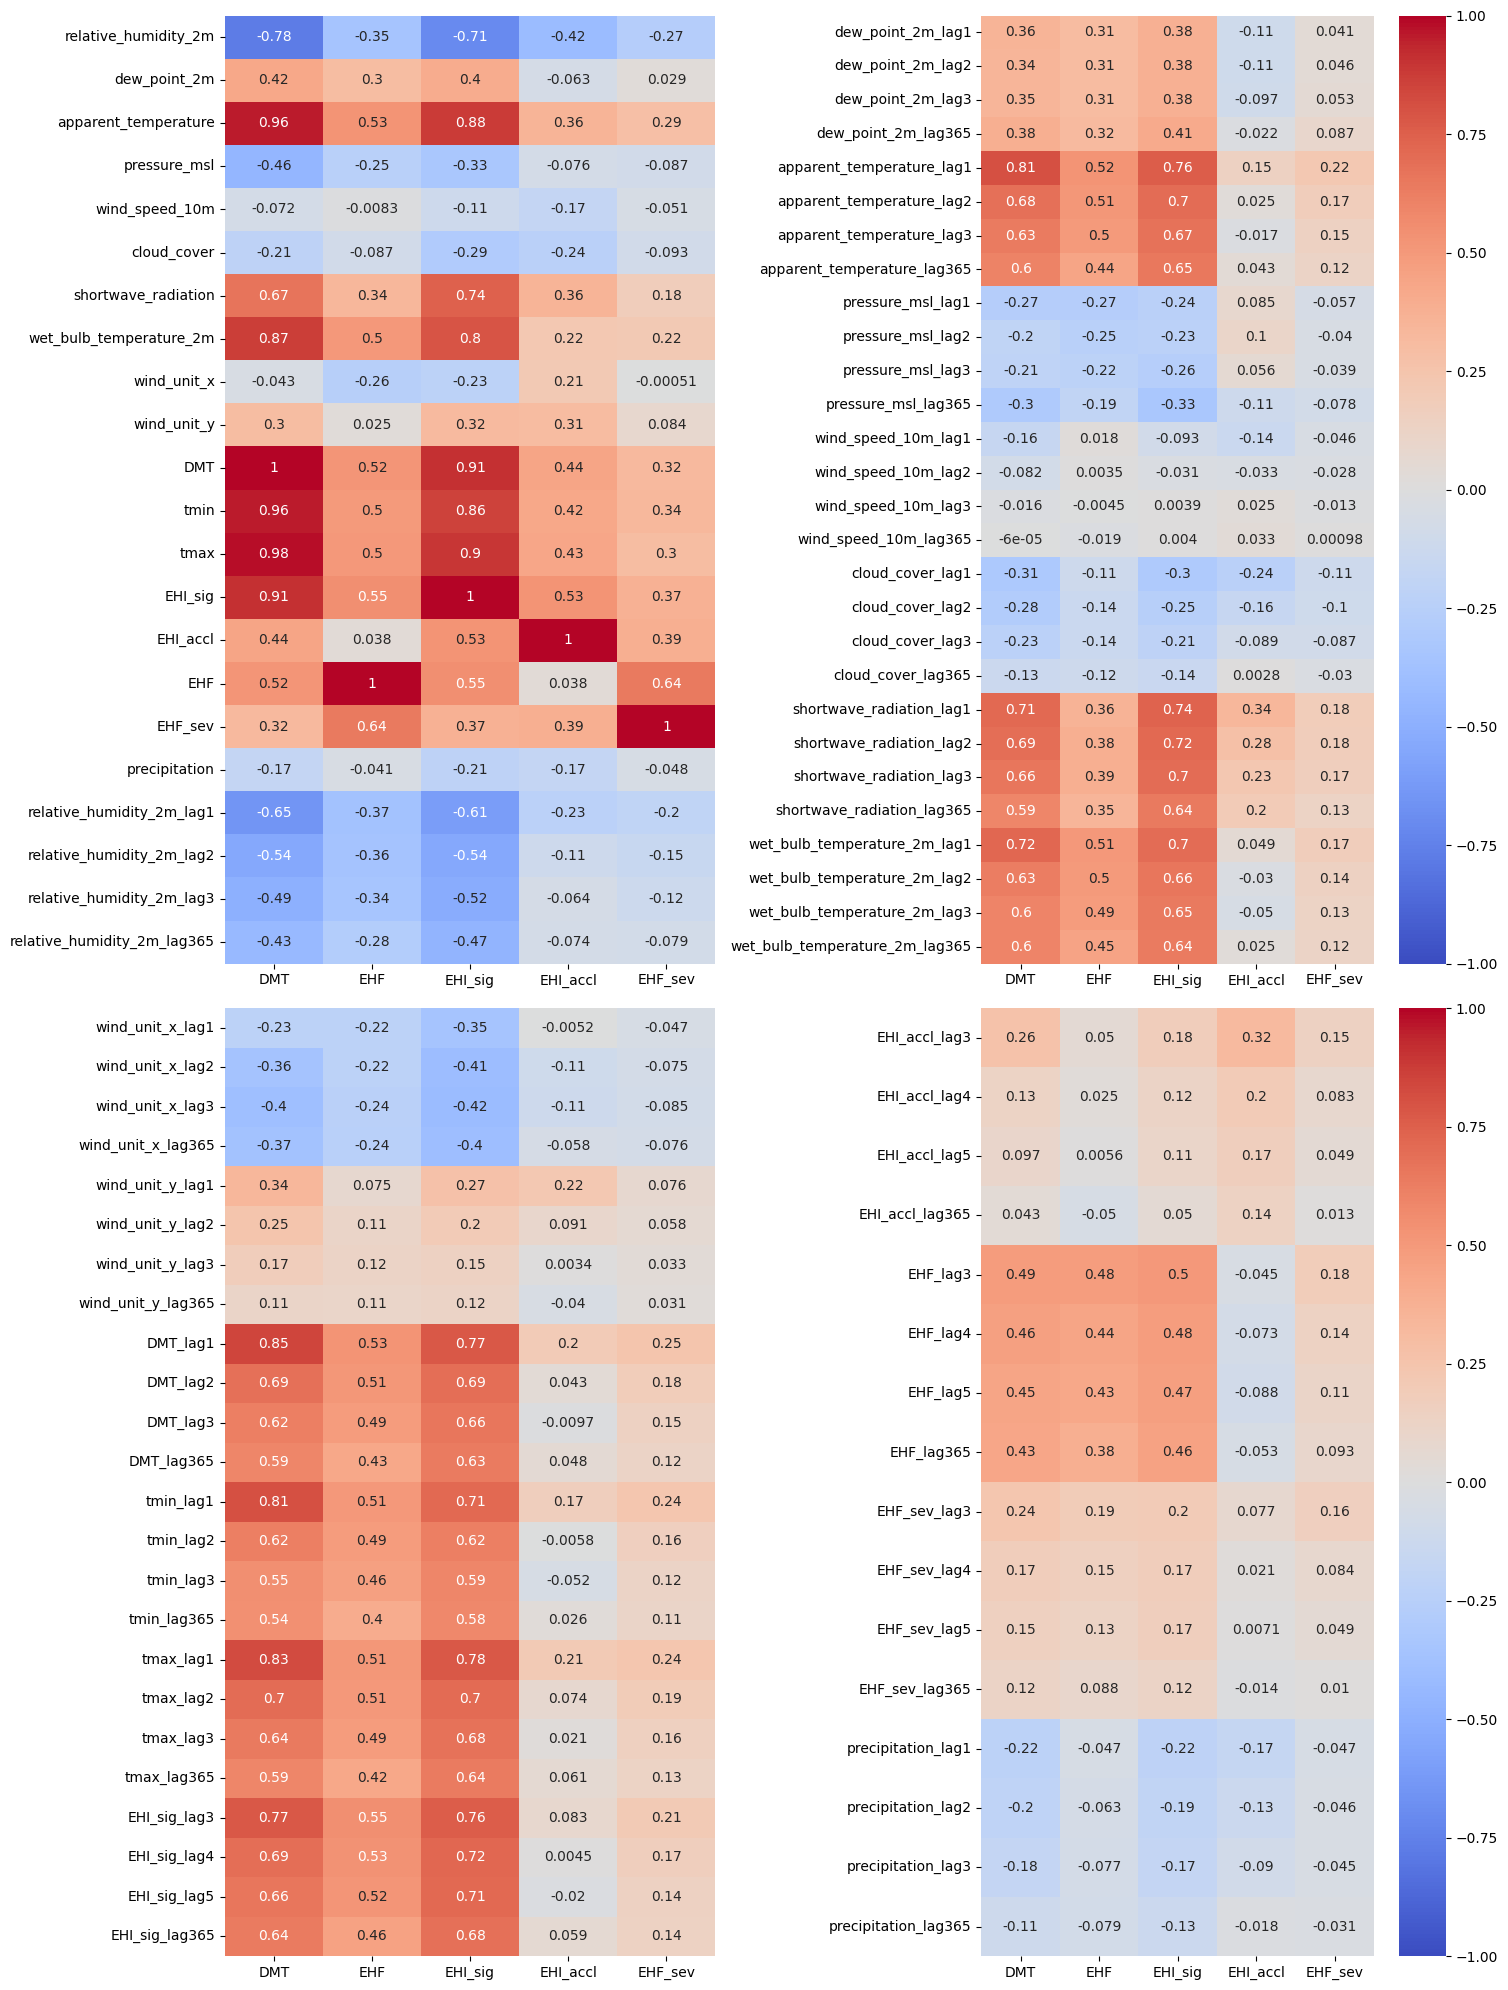

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(15, 20))
EHF_cols = ['DMT', 'EHF', 'EHI_sig', 'EHI_accl', 'EHF_sev']

sns.heatmap(lag_corr.loc[lag_corr.columns[0:22], EHF_cols], 
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', cbar=False, ax=ax[0, 0])
sns.heatmap(lag_corr.loc[lag_corr.columns[22:50], EHF_cols], 
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=ax[0, 1])
sns.heatmap(lag_corr.loc[lag_corr.columns[50:74], EHF_cols],  
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', cbar=False, ax=ax[1, 0])
sns.heatmap(lag_corr.loc[lag_corr.columns[74:len(lag_corr.columns)], EHF_cols], 
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=ax[1, 1])
fig.tight_layout()
plt.show()      

We can see a lot of similar correlation values, spesifically between multicollinear features. Almost all features, we can see that as lag increases correlation values slowly decrease, which is an expected behaviour of lag features, in general. We will not do any feature selection or analysis at this point. We are going to handle multicollinearity problem in a future section, that comes after all potential features are derived. 

# Moving/Rolling Features

Motivation of using rolling features is to capture temporal patterns like trends, seasonality, etc. Because we don't use seperate trend or seasonality features with traditional machine learning models, like we use statistical time series models like ARIMA, ETS, etc. 


**Rolling Feature Main Features:** `DMT`, `tmin`, `tmax`, `EHI_sig`, `EHF`, `shortwave_radiation`, `relative_humidity_2m`, `wind_unit_x`, `wind_unit_y`, `wind_speed_10m`, `pressure_msl`, `precipitation`.

We are going to derive **3 days mean/sum, 3 days std., 7 days mean/sum, 7 days std.** of each of these main features.

As you can see we don't incluede some features like `apparent_temperature` and `wet_bulb_temperature_2m`. The reason is, they have high correlation of some of the included features like `DMT`, `tmin`. So, inclueded features' rolling features already will have most of the information that rolling features of excluded features would have. We produce 4 new features for each inclueded feature. We consider exclueding those features as an initial feature selection step.

In [5]:
moving_cols = ['DMT', 'tmin', 'tmax', 'EHI_sig', 'EHF', 'shortwave_radiation', 
               'relative_humidity_2m', 'wind_unit_x', 'wind_unit_y', 'wind_speed_10m', 
               'pressure_msl', 'precipitation'] 

In [15]:
moving_feats = daily_df.loc[:, moving_cols].copy()

# We shift all variables by 1 day to avoid data leakage
for c in moving_cols:
    if col.startswith('EH'): 
        moving_feats[f'{c}_avg3'] = moving_feats[c].shift(3).rolling(3).mean()
        moving_feats[f'{c}_avg7'] = moving_feats[c].shift(3).rolling(7).mean()
        moving_feats[f'{c}_std3'] = moving_feats[c].shift(3).rolling(3).std()
        moving_feats[f'{c}_std7'] = moving_feats[c].shift(3).rolling(7).std()
        continue
        # To avoid data leakage, we start from 3 days before and go backwards as many days as rolling parameter minus 1.
        # (Minus 1 because starting day is included too.)

    if c == 'precipitation':    
        moving_feats[f'{c}_sum3'] = moving_feats[c].rolling(3).sum().shift(1)  
        moving_feats[f'{c}_sum7'] = moving_feats[c].rolling(7).sum().shift(1)
    else:
        moving_feats[f'{c}_avg3'] = moving_feats[c].rolling(3).mean().shift(1)
        moving_feats[f'{c}_avg7'] = moving_feats[c].rolling(7).mean().shift(1)

    moving_feats[f'{c}_std3'] = moving_feats[c].rolling(3).std().shift(1)
    moving_feats[f'{c}_std7'] = moving_feats[c].rolling(7).std().shift(1)

In [16]:
moving_corr = moving_feats.corr()

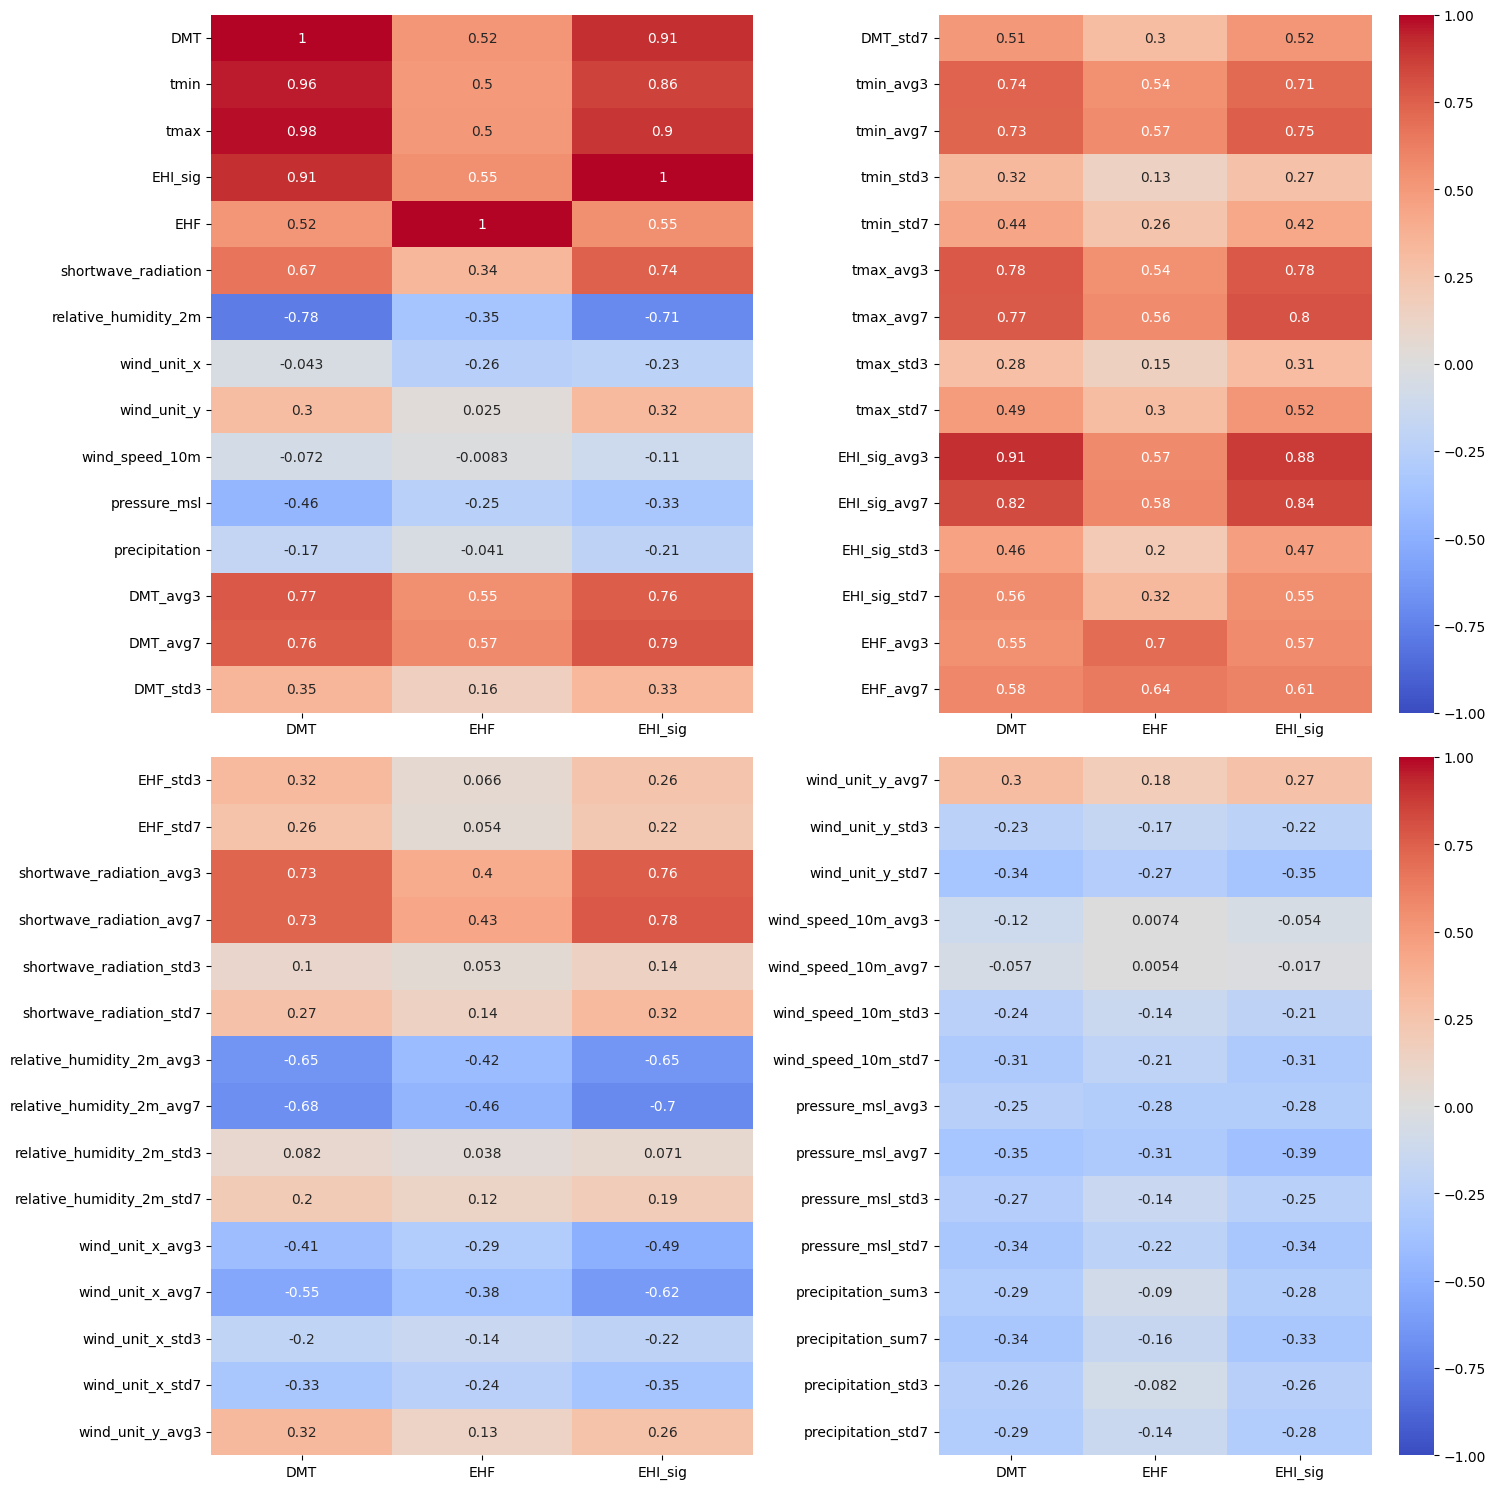

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(15, 15))
EHF_cols = ['DMT', 'EHF', 'EHI_sig']

sns.heatmap(moving_corr.loc[moving_corr.columns[0:15], EHF_cols], 
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', cbar=False, ax=ax[0, 0])
sns.heatmap(moving_corr.loc[moving_corr.columns[15:30], EHF_cols], 
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=ax[0, 1])
sns.heatmap(moving_corr.loc[moving_corr.columns[30:45], EHF_cols],  
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', cbar=False, ax=ax[1, 0])
sns.heatmap(moving_corr.loc[moving_corr.columns[45:len(moving_corr.columns)], EHF_cols], 
            annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=ax[1, 1])
fig.tight_layout()
plt.show()

**!!** There is a fact to be noticed here. Some of *wind related features' and pressure features'* rolling stat correlations with `DMT`, `EHF` and `EHI_sig`  are higher than pointwise associated lag feature values. Which might means that, recent time wind and pressure overall dynamics either effect or are related to local temperatures. This might worth to investigate seperately for more scientific purposes in future, rather than feature engineering and predictive modelling perspectives.

# Month Features 

## Cyclic Month Columns
As we've mentioned earlier in `Introduction and Motivation` section above, we need to derive cyclic month columns consist of `month_cyc_x` and `month_cyc_y` features. Model can learn the month by these two columns, and might learn other features' yearly seasonal patterns by combining them.

In [18]:
cyclic_month = pd.DataFrame(daily_df['month_local'])
cyclic_month.head()

,month_local
datetime_local,
2000-01-01 00:00:00+10:30,1.0
2000-01-02 00:00:00+10:30,1.0
2000-01-03 00:00:00+10:30,1.0
2000-01-04 00:00:00+10:30,1.0
2000-01-05 00:00:00+10:30,1.0


In [19]:
cyclic_month['month_cyc_x'] = np.cos(2 * np.pi * cyclic_month['month_local'] / 12)
cyclic_month['month_cyc_y'] = np.sin(2 * np.pi * cyclic_month['month_local'] / 12)
cyclic_month.head()

,month_local,month_cyc_x,month_cyc_y
datetime_local,,,
2000-01-01 00:00:00+10:30,1.0,0.866025,0.5
2000-01-02 00:00:00+10:30,1.0,0.866025,0.5
2000-01-03 00:00:00+10:30,1.0,0.866025,0.5
2000-01-04 00:00:00+10:30,1.0,0.866025,0.5
2000-01-05 00:00:00+10:30,1.0,0.866025,0.5


## Previous Years Monthly Means 

In [20]:
prev_cols = ['DMT', 'tmin', 'tmax', 'EHF', 'EHI_sig', 'EHF_sev', 'relative_humidity_2m', 'month_local']  

We will be already providing month and original features to models by cyclic month features. Just in case, still previous years monthly means might useful for models to find out extra patterns, we derive and add them to big feature list.   

In [21]:
prev_month_df = daily_df[prev_cols].copy()

for c in prev_cols:
    prev_month_df[f"{c}_month_mean"] = prev_month_df[c]
    prev_month_df[f"{c}_month_mean"] = np.nan

prev_month_df.head()

,DMT,tmin,tmax,EHF,EHI_sig,EHF_sev,relative_humidity_2m,month_local,DMT_month_mean,tmin_month_mean,tmax_month_mean,EHF_month_mean,EHI_sig_month_mean,EHF_sev_month_mean,relative_humidity_2m_month_mean,month_local_month_mean
datetime_local,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,16.015000,12.29,19.740000,-8.062083,-8.062083,0.0,58.375954,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 00:00:00+10:30,19.690000,13.89,25.490000,-7.820417,-7.820417,0.0,53.894292,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03 00:00:00+10:30,18.989999,12.79,25.189999,-8.895417,-8.895417,0.0,59.922957,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04 00:00:00+10:30,16.740000,13.14,20.340000,-9.395417,-9.395417,0.0,51.373941,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05 00:00:00+10:30,16.465000,11.89,21.039999,-8.628750,-8.628750,0.0,54.446861,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
for y in range(2001, 2025):
    for c in prev_cols:
        mask = ((daily_df.index.year >= 2000) & (daily_df.index.year < y)) # Mask for previous years
        monthly_means = daily_df.loc[mask, c].groupby(daily_df[mask].index.month).mean()
        for m in range(1, 13):
            prev_month_df.loc[f"{y}-{m}", f"{c}_month_mean"] = monthly_means[m]

In [23]:
prev_month_df.drop(columns=['month_local_month_mean'], inplace=True)

In [24]:
prev_month_df

,DMT,tmin,tmax,EHF,EHI_sig,EHF_sev,relative_humidity_2m,month_local,DMT_month_mean,tmin_month_mean,tmax_month_mean,EHF_month_mean,EHI_sig_month_mean,EHF_sev_month_mean,relative_humidity_2m_month_mean
datetime_local,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,16.015000,12.290000,19.740000,-8.062083,-8.062083,0.0,58.375954,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 00:00:00+10:30,19.690000,13.890000,25.490000,-7.820417,-7.820417,0.0,53.894292,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03 00:00:00+10:30,18.989999,12.790000,25.189999,-8.895417,-8.895417,0.0,59.922957,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04 00:00:00+10:30,16.740000,13.140000,20.340000,-9.395417,-9.395417,0.0,51.373941,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05 00:00:00+10:30,16.465000,11.890000,21.039999,-8.628750,-8.628750,0.0,54.446861,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27 00:00:00+10:30,18.312500,16.537500,20.087500,-8.047917,-8.047917,0.0,55.261715,12.0,20.587387,15.7054,25.469375,-6.459641,-5.586451,0.056721,55.359948
2024-12-28 00:00:00+10:30,17.787500,14.637500,20.937500,-7.139583,-7.139583,0.0,64.383871,12.0,20.587387,15.7054,25.469375,-6.459641,-5.586451,0.056721,55.359948
2024-12-29 00:00:00+10:30,18.637500,14.287499,22.987500,-6.031250,-6.031250,0.0,69.666988,12.0,20.587387,15.7054,25.469375,-6.459641,-5.586451,0.056721,55.359948


Obviously we can't have any first year (2000) value for any of these newly derived `month_mean` features. We should keep mind that we have to drop first year rows before modelling.

# Merging All Potential Features

We need to merge all potential derived features to big feature dataframe.

In [25]:
only_lag_cols = [c for c in lag_df.columns if c not in daily_df.columns]
only_moving_cols = [c for c in moving_feats.columns if c not in daily_df.columns]
only_cyclic_cols = [c for c in cyclic_month.columns if c not in daily_df.columns]
only_prev_cols = [c for c in prev_month_df.columns if c not in daily_df.columns]

In [26]:
all_feats_df = daily_df.copy()
# Merging all feature columns
all_feats_df = all_feats_df.join(lag_df[only_lag_cols], how='left')
all_feats_df = all_feats_df.join(moving_feats[only_moving_cols], how='left')
all_feats_df = all_feats_df.join(cyclic_month[only_cyclic_cols], how='left')
all_feats_df = all_feats_df.join(prev_month_df[only_prev_cols], how='left')
len(all_feats_df.columns)

151

All potential features.

In [27]:
all_feats_df.to_csv('data/processed/daily_all_features.csv', index=True, index_label='datetime_local')

In [5]:
all_feats_df = pd.read_csv("data/processed/daily_all_features.csv", index_col="datetime_local")
all_feats_df.index = pd.to_datetime(all_feats_df.index, utc=True).tz_convert("Australia/Adelaide")
all_feats_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,precipitation_std7,month_cyc_x,month_cyc_y,DMT_month_mean,tmin_month_mean,tmax_month_mean,EHF_month_mean,EHI_sig_month_mean,EHF_sev_month_mean,relative_humidity_2m_month_mean
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,NaN,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,NaN,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,NaN,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,NaN,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,NaN,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We have produced our potential features, so far so good. But we do have a big feature space for a relatively small data set, ~9000 rows, for traditional ML models. We will be using them rather than deep learning based models which are more suitable for big data and can do feature selection in it. It is good to handle task as simple as possible. Thus, it is our goal to reduce feature space to more acceptable levels.

# Multicollinear Feature Clustering

First and most obvious step to approach feature selection is handling multicollinearity. We are going to touch and handle this matter in this section before we end the notebook. 

We are going to use **Principle Component Analysis (PCA)** to reduce multicollinear features' dimensionality. To detect multicollinearities more technically, we are going to use **hierarchical clustering**. 

**! Method and Logic:** To put what we're going to simply: We are going to produce full correlation matrix, and consider each value as a *reverse distance* between associated two features. Means, we consider that as much as *absolute correlation* is high then two features are close to each other. Then we can think them as some sort of opposite of geometrical distance. So, we can consider ""**1 - absolute correlation**"" values as distances between features. While we have distances between each other, we can group features they are close to each other. This can be done unsupervised clustering techniques. Since, we do have manageable amount of features we could use hierarchical clustering technique and get benefit of its interpretability and visualization. 

Before we get into clustering:

**Columns those should not be used for directly in modelling:** *['wind_direction_compass', 'month_local', 'severity', 'heat_wave']*. First two are categorical features. We already have their numerical representations among the features. Last two are potential classification labels. 

In [ ]:
drop_cols = ['wind_direction_compass', 'month_local', 'severity', 'heat_wave']
all_feats_df.drop(columns=drop_cols, inplace=True)

In [6]:
# Imports
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

In [ ]:
# Candidate features for multicollinear clustering
numerical_feats = list(all_feats_df.select_dtypes('number').columns)

In [ ]:
# Correlation matrix
all_feats_corr = all_feats_df[numerical_feats].corr()

In [ ]:
corr_dist = 1 - all_feats_corr.abs() # Distances in squared form
sqr_corr_dist = squareform(corr_dist) # Convert square matrix to vector

In [ ]:
# Calculate links with distances 
Z = linkage(sqr_corr_dist, method='average')

In [ ]:
threshold = 1 - 0.75 

**!** We want to cluster features with correlation higher than **0.75** threshold. In other words, all features in a cluster must have minimum 0.75 *absolute correlation* with rest of the features. 

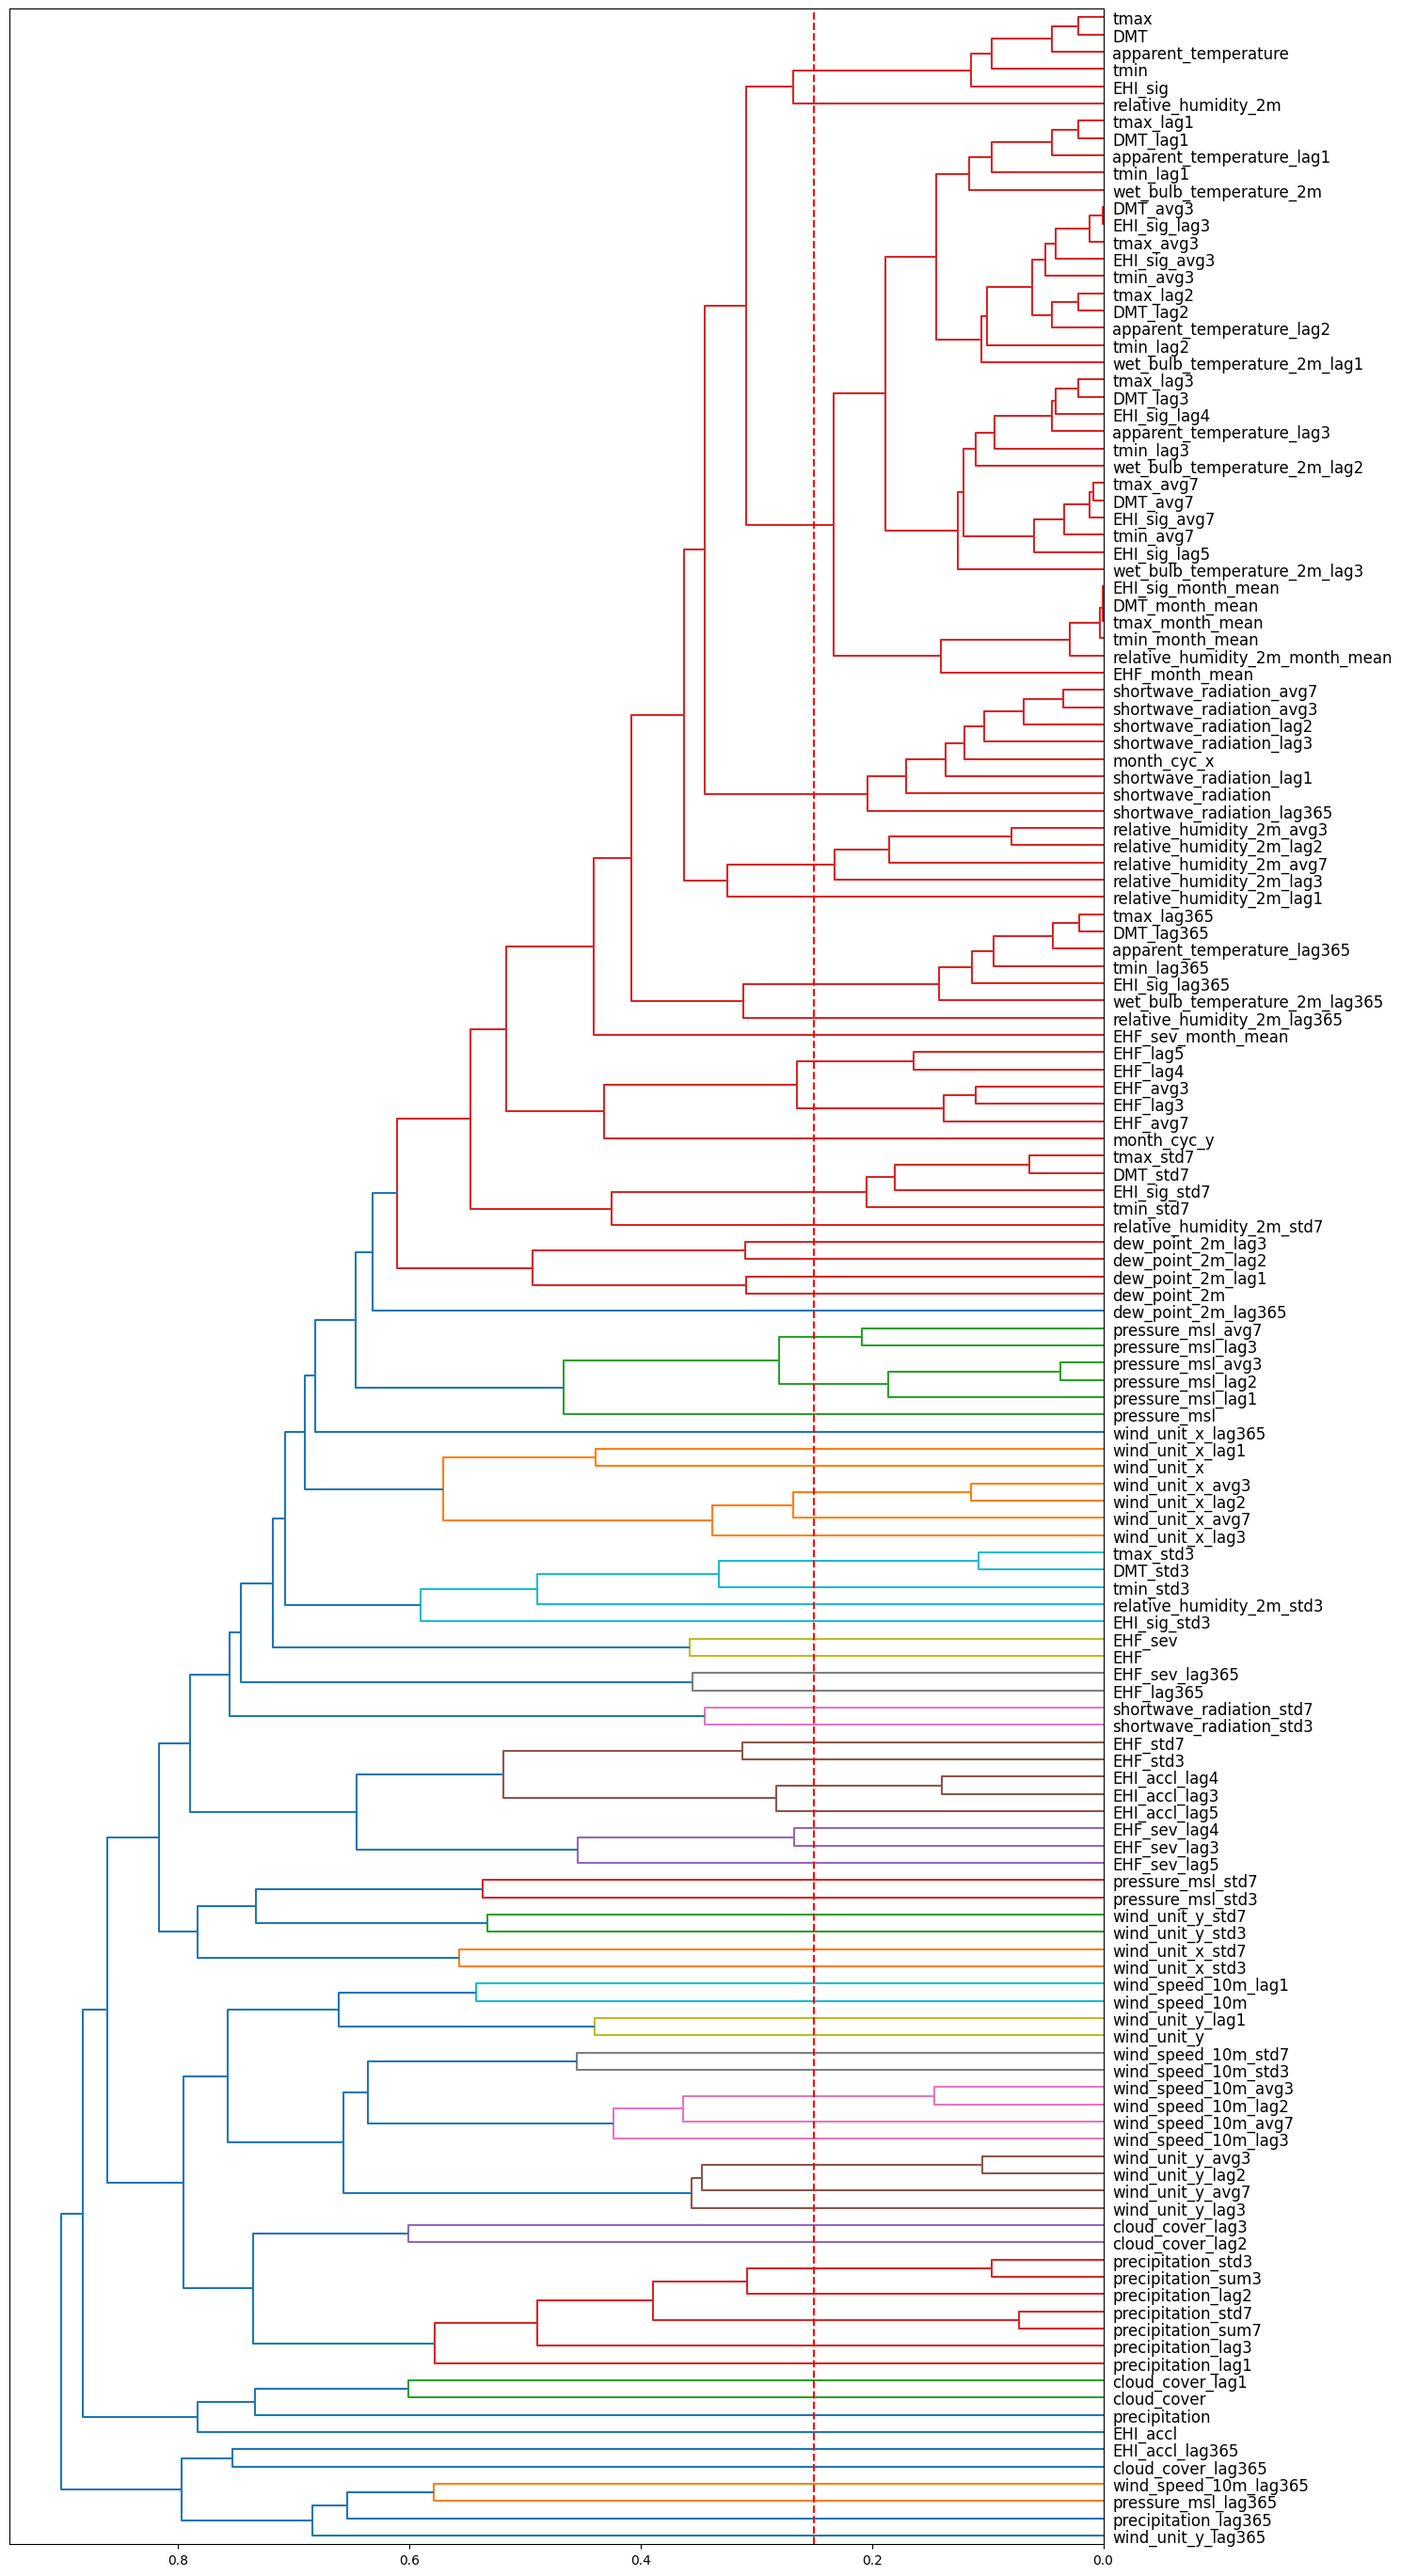

In [13]:
# Plot the dendrogram
plt.figure(figsize=(15, 35))
dendrogram(Z, 
           labels=all_feats_corr.columns, 
           leaf_font_size=12,
           orientation="left")
plt.axvline(x=threshold, color='r', linestyle='--')
plt.show()

Now, this is the interpretability and visualization we've mentioned earlier. Basically, **feature branches merges at distance values between them**. *Red dashed line is our threshold*. We are going to group features that merged at right side of this line. For example, if we look to top of features, we can see that `tmax, DMT, apparent_temperature, tmin, EHI_sig` consist of a cluster. `relative_humidity_2m` is just out of the cluster.

*We can see an overall cluster pattern:* Features have same root are close each other. Like *wind* related features ordered next to each other, or *precipitation* related features. At top, we can see temperature plus humidity related high correlation group. We've seen those during the explonatory data analysis and feature engineering steps. 

**! But**, one interesting thing is `month_cyc_x` and `month_cyc_y` cyclic month features are grouped with temperature related features. At first, it sounds weird. But if we think mathematically on a unit circle, two end points of circle matches with two end months actually. Most obvious and explanatory would be thinking for *January* and *July*. January is $[0.86, 0.5]$ and July is $[-0.86, -0.5]$ on unit circle. When time proceeds from *January* to *July*, month *'x'*  value decreases gradually, and month *'y'* value first increases then decreases. By yhe way, these progressions are not linear. Still, their directions with daily temperature directions aligns at some degree: In this time process, temperatures are decreasing for south hemisphere. And vice versa also happens, which is from *July* to *January*. One last detail for this spesific case is, `month_cyc_x` distance with temperature related features is closer than distances with `month_cyc_y`. Most obvious reason is, we've just touched `month_cyc_x` behaves monotonic over half years, while `month_cyc_y` is not totaly, which increases and decreases over time.  

In [ ]:
# Creating clusters based on specified threshold
clusters = fcluster(Z, t=threshold, criterion='distance')

feature_groups = (
    pd.DataFrame({'feature': all_feats_corr.columns, 'cluster': clusters})
    .groupby('cluster')['feature']
    .apply(list)
)

In [13]:
feature_groups

cluster
1                                [pressure_msl_lag365]
2                              [wind_speed_10m_lag365]
3                               [precipitation_lag365]
4                                 [wind_unit_y_lag365]
5                                 [cloud_cover_lag365]
                            ...                       
76    [apparent_temperature, DMT, tmin, tmax, EHI_sig]
77                              [relative_humidity_2m]
78                                [EHF_sev_month_mean]
79                               [dew_point_2m_lag365]
80                                [wind_unit_x_lag365]
Name: feature, Length: 80, dtype: object

A lot of features are not included in any of the feature groups as we can see. We'll clean those down below.

In [14]:
feature_groups_lengths = feature_groups.apply(len)
feature_groups_lengths

cluster
1     1
2     1
3     1
4     1
5     1
     ..
76    5
77    1
78    1
79    1
80    1
Name: feature, Length: 80, dtype: int64

**Features those should be not inclueded any dimensionality reduction group:** *[month_cyc_x, month_cyc_y]* and all *'wind_unit' prefixed features*. 

Still we've spesifically discussed about the mathematical feasibility and reason of month cyclic features are inclueded in feature groups up above, we want to exclude them from dimensionality reduction groups and use them seperately. Because these are shows some cyclic dynamics, interpretations. Time is a main factor when it comes to climate, most spesifically temperatures. We don't want to cover this interprebability with dimensionality reduction.

For wind directions, we've seen that wind directions might have some spesific patterns with heatwaves. We don't want to cover them, hence model might learn and show us some patterns that might have some worth of scientific hypothesis and ideas.

In [ ]:
no_dim_reduce_cols = ['month_cyc_x', 'month_cyc_y']
for c in all_feats_df.columns:
    if c.startswith('wind_unit'):
        no_dim_reduce_cols.append(c)

no_dim_reduce_cols

['month_cyc_x',
 'month_cyc_y',
 'wind_unit_x',
 'wind_unit_y',
 'wind_unit_x_lag1',
 'wind_unit_x_lag2',
 'wind_unit_x_lag3',
 'wind_unit_x_lag365',
 'wind_unit_y_lag1',
 'wind_unit_y_lag2',
 'wind_unit_y_lag3',
 'wind_unit_y_lag365',
 'wind_unit_x_avg3',
 'wind_unit_x_avg7',
 'wind_unit_x_std3',
 'wind_unit_x_std7',
 'wind_unit_y_avg3',
 'wind_unit_y_avg7',
 'wind_unit_y_std3',
 'wind_unit_y_std7']

Let's exclude all these `no_dim_reduce_cols` from all the feature groups.

In [16]:
for i in feature_groups.index:
    l = list(feature_groups[i])
    l = [c for c in l if c not in no_dim_reduce_cols]
    feature_groups[i] = l

feature_groups 

cluster
1                                [pressure_msl_lag365]
2                              [wind_speed_10m_lag365]
3                               [precipitation_lag365]
4                                                   []
5                                 [cloud_cover_lag365]
                            ...                       
76    [apparent_temperature, DMT, tmin, tmax, EHI_sig]
77                              [relative_humidity_2m]
78                                [EHF_sev_month_mean]
79                               [dew_point_2m_lag365]
80                                                  []
Name: feature, Length: 80, dtype: object

In [ ]:
# Cleaning empty groups and groups with only one feature
feature_groups = feature_groups[feature_groups.apply(len) > 1]

In [18]:
feature_groups.index = range(len(feature_groups))
feature_groups

0              [precipitation_sum7, precipitation_std7]
1              [precipitation_sum3, precipitation_std3]
2            [wind_speed_10m_lag2, wind_speed_10m_avg3]
3                        [EHI_accl_lag3, EHI_accl_lag4]
4                                 [DMT_std3, tmax_std3]
5     [pressure_msl_lag1, pressure_msl_lag2, pressur...
6                [pressure_msl_lag3, pressure_msl_avg7]
7        [DMT_std7, tmin_std7, tmax_std7, EHI_sig_std7]
8                        [EHF_lag3, EHF_avg3, EHF_avg7]
9                                  [EHF_lag4, EHF_lag5]
10    [apparent_temperature_lag365, wet_bulb_tempera...
11    [relative_humidity_2m_lag2, relative_humidity_...
12    [shortwave_radiation, shortwave_radiation_lag1...
13    [wet_bulb_temperature_2m, apparent_temperature...
14     [apparent_temperature, DMT, tmin, tmax, EHI_sig]
Name: feature, dtype: object

## Classification Features

**Current day features those must not be used:** *['DMT', 'tmin', 'EHF', 'EHI_sig', 'EHI_accl', 'EHF_sev']*. This is the point we are explaning the statement *"some of today's features"* we've made at the beginning of this, in `Introduction and Motivation` section.
These columns cause data leakage, by either their definition or our modeling goal.

**!!!!!** Heatwave index features (starts with *'EH'*) derived from today's and consecutive 2 days' temperature values. $DMT = (\text{tmin} + \text{tmax})/2$ as we might remember. The subtle and actually most important point is, if we can acquire a feature end of today we can use it with respect to our predictive modelling goal. In this case we can use, `apparent_temperature`, `relative_humidity_2m`, `pressure_msl`, `precipitation` etc. features. Because they are produced as day's either mean or summation value. **! HOWEVER:** When we think about `tmax` and `tmin` they are the minimum and maximum temperature values from **today's 9am to tomorrow's 9am**. When we consider from perspective of physical laws; `tmax` should happen between *today's 9am* and actual end of the day, *night 00.00 am*, but `tmin` might happen between todays end of the day *night 00.00 am* and *tomorrow's 9am*. So, there is a possibility of we can't learn correct `tmin` even after day ends. Actually it is a possibility, we can't know the correct answer without completing the experiment, which is reaching the tomarow's 9am. Because of this reason, we can't use `tmin`, but still can use `tmax`. Since we can't use `tmin`, we can't implicitly use `DMT` too.

In [19]:
from src.general_utils import pca_by_feature_groups

In [23]:
unusable_for_classification = ['DMT', 'tmin', 'EHF', 'EHI_sig', 'EHI_accl', 'EHF_sev']

pca_results_cls, fg_cls = pca_by_feature_groups(
    feature_groups=feature_groups,
    df=all_feats_df,
    unusable_cols=unusable_for_classification
)

In [24]:
fg_cls

,feature_group,group_size,cumulative_pve
0,"[precipitation_sum7, precipitation_std7]",2,"[0.9635903670948435, 1.0]"
1,"[precipitation_sum3, precipitation_std3]",2,"[0.9519504301550225, 0.9999999999999999]"
2,"[wind_speed_10m_lag2, wind_speed_10m_avg3]",2,"[0.9269007706676774, 0.9999999999999999]"
3,"[EHI_accl_lag3, EHI_accl_lag4]",2,"[0.9302000255077699, 1.0]"
4,"[DMT_std3, tmax_std3]",2,"[0.9459727593038323, 1.0]"
5,"[pressure_msl_lag1, pressure_msl_lag2, pressur...",3,"[0.909740388413776, 0.9902699932238705, 1.0]"
6,"[pressure_msl_lag3, pressure_msl_avg7]",2,"[0.8955354159430747, 0.9999999999999999]"
7,"[DMT_std7, tmin_std7, tmax_std7, EHI_sig_std7]",4,"[0.871257895032853, 0.9461741317268824, 0.9979..."
8,"[EHF_lag3, EHF_avg3, EHF_avg7]",3,"[0.9143955048675078, 0.9651845997143979, 0.999..."
9,"[EHF_lag4, EHF_lag5]",2,"[0.9182199172946198, 1.0000000000000002]"


When we check *cumulative proportion variance explained* values, almost every groups first principal component explains at least 90% variance. We are targeting at least 85-90% variance in each group. According to that: 
* **PC1 groups:** *[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14]*
* **PC1, PC2 groups:** *[11, 12]*
* **PC1, PC2, PC3 groups:** *[13]*

In [25]:
fg_cls['to_be_used_pcs'] = fg_cls['group_size']
fg_cls.loc[0:10, 'to_be_used_pcs'] = 1
fg_cls.loc[11:12, 'to_be_used_pcs'] = 2
fg_cls.loc[13, 'to_be_used_pcs'] = 3
fg_cls.loc[14, 'to_be_used_pcs'] = 1

fg_cls

,feature_group,group_size,cumulative_pve,to_be_used_pcs
0,"[precipitation_sum7, precipitation_std7]",2,"[0.9635903670948435, 1.0]",1
1,"[precipitation_sum3, precipitation_std3]",2,"[0.9519504301550225, 0.9999999999999999]",1
2,"[wind_speed_10m_lag2, wind_speed_10m_avg3]",2,"[0.9269007706676774, 0.9999999999999999]",1
3,"[EHI_accl_lag3, EHI_accl_lag4]",2,"[0.9302000255077699, 1.0]",1
4,"[DMT_std3, tmax_std3]",2,"[0.9459727593038323, 1.0]",1
5,"[pressure_msl_lag1, pressure_msl_lag2, pressur...",3,"[0.909740388413776, 0.9902699932238705, 1.0]",1
6,"[pressure_msl_lag3, pressure_msl_avg7]",2,"[0.8955354159430747, 0.9999999999999999]",1
7,"[DMT_std7, tmin_std7, tmax_std7, EHI_sig_std7]",4,"[0.871257895032853, 0.9461741317268824, 0.9979...",1
8,"[EHF_lag3, EHF_avg3, EHF_avg7]",3,"[0.9143955048675078, 0.9651845997143979, 0.999...",1
9,"[EHF_lag4, EHF_lag5]",2,"[0.9182199172946198, 1.0000000000000002]",1


Eventually, we got the clusters and the number of PCs to be used for each group. We are going to save this to use during feature selection and model training.

In [ ]:
fg_cls.to_csv('data/processed/fg_cls.csv', index=False) # Saving to use during model training.c

## Regression Features

**! Note:** This section created before we clarify the decision of proceeding with binary classification as a main predictive goal. In case of we might do regression modelling as well in future, we keep this part in notebook too.

**Columns those should not be used:** Because of our modeling goal, we should not use any features from same day we are going to be predicting `DMT` or `EHF` of. Which means, this set covers all same day features: All ``daily_df.columns``.

In [32]:
unusable_for_regression = list(daily_df.columns)

pca_results_regg, fg_regg = pca_by_feature_groups(
    feature_groups=feature_groups,
    df=all_feats_df,
    unusable_cols=unusable_for_regression
)

In [33]:
fg_regg

,feature_group,group_size,cumulative_pve
0,"[precipitation_sum7, precipitation_std7]",2,"[0.9635903670948435, 1.0]"
1,"[precipitation_sum3, precipitation_std3]",2,"[0.9519504301550225, 0.9999999999999999]"
2,"[wind_speed_10m_lag2, wind_speed_10m_avg3]",2,"[0.9269007706676774, 0.9999999999999999]"
3,"[EHI_accl_lag3, EHI_accl_lag4]",2,"[0.9302000255077699, 1.0]"
4,"[DMT_std3, tmax_std3]",2,"[0.9459727593038323, 1.0]"
5,"[pressure_msl_lag1, pressure_msl_lag2, pressur...",3,"[0.909740388413776, 0.9902699932238705, 1.0]"
6,"[pressure_msl_lag3, pressure_msl_avg7]",2,"[0.8955354159430747, 0.9999999999999999]"
7,"[DMT_std7, tmin_std7, tmax_std7, EHI_sig_std7]",4,"[0.871257895032853, 0.9461741317268824, 0.9979..."
8,"[EHF_lag3, EHF_avg3, EHF_avg7]",3,"[0.9143955048675078, 0.9651845997143979, 0.999..."
9,"[EHF_lag4, EHF_lag5]",2,"[0.9182199172946198, 1.0000000000000002]"


It seems using same amount of PCs for each group as we've decided for classification features would be good enough. Exception with one group, that is last group, 14th index. We actually don't have any features in that group because of all or most of them among ``unusable_for_regression``. We'll past its `to_be_used_pcs` value as 0.

In [34]:
fg_regg['to_be_used_pcs'] = fg_cls['to_be_used_pcs']
fg_regg.loc[14, 'to_be_used_pcs'] = 0
fg_regg

,feature_group,group_size,cumulative_pve,to_be_used_pcs
0,"[precipitation_sum7, precipitation_std7]",2,"[0.9635903670948435, 1.0]",1
1,"[precipitation_sum3, precipitation_std3]",2,"[0.9519504301550225, 0.9999999999999999]",1
2,"[wind_speed_10m_lag2, wind_speed_10m_avg3]",2,"[0.9269007706676774, 0.9999999999999999]",1
3,"[EHI_accl_lag3, EHI_accl_lag4]",2,"[0.9302000255077699, 1.0]",1
4,"[DMT_std3, tmax_std3]",2,"[0.9459727593038323, 1.0]",1
5,"[pressure_msl_lag1, pressure_msl_lag2, pressur...",3,"[0.909740388413776, 0.9902699932238705, 1.0]",1
6,"[pressure_msl_lag3, pressure_msl_avg7]",2,"[0.8955354159430747, 0.9999999999999999]",1
7,"[DMT_std7, tmin_std7, tmax_std7, EHI_sig_std7]",4,"[0.871257895032853, 0.9461741317268824, 0.9979...",1
8,"[EHF_lag3, EHF_avg3, EHF_avg7]",3,"[0.9143955048675078, 0.9651845997143979, 0.999...",1
9,"[EHF_lag4, EHF_lag5]",2,"[0.9182199172946198, 1.0000000000000002]",1


In [35]:
fg_regg.to_csv('data/processed/fg_regg.csv', index=False) # Saving to use during model training.

# One Extra Feature 

Before we end this notebook, lastly, we want to add previous 30 days average DMT among our features. Because it is used to calculate $EHI_{accl}$, it would most likely be useful to predict heatwaves. Because we don't want it to incluede any feature group, we are adding it into our features here seperately.

In [7]:
all_feats_df['DMT_avg30'] = all_feats_df['DMT'].rolling(30).mean().shift(1)

In [9]:
all_feats_df.to_csv('data/processed/daily_all_features.csv', index=True, index_label='datetime_local')

# Outro and Conclusion

Eventaully, in this notebook, we've prepared `all_feats_df` full feature dataframe, `fg_cls` and `fg_regg` feature groups dataframes to use during feature selection and model training.

# Bottom